Model: Linear Regression
- Only applicable for datasets with a single input feature.
- If we can fit the data in the dataset into a straight line, we can use Linear Regression.
- The objective is to find the straight line that best fits the data.
- Equation of straight line: `Y = MX + C`. We need to find the correct values of `M` and `C`.
- Calculate the slope using $\text {slope} = \frac {y_2-y_1}{x_2-x_1}$.
- How to find the line? Find the one with the `Least Mean Square Error` for all data points, that's the line with the best fit.
- For minimizing the MSE, we use the `Gradient Descent Method`.
- For maximizing the MSE, we use the `Gradient Ascent Method`.
- Process:
    - For each line we predict, we will calculate the `Mean Squared Error`, which is ${(\bar y - y)}^2$.
    - To find the least MSE, we use the `Gradient Descent Method`.
        - We decide whether to increase or decrease the `m` value.
        - Initially, $m=7$.
        - According to the graph, we're past the MSE. So, we decrease the value (let in steps of 3).
        - Next, $m=4$, which has the least MSE.

## `Gradient Descent Method`
- `Gradient`: Slope
- It is a first order optimizer, and we take steps proportional to the negative of the gradient of the function.
- The objective of this method is find the optimal `m` value.
- $m_{new}=m_{old} - \alpha * (\delta *m_{old})$
- Find the slope, $\text{slope} = \frac {y_2-y_1}{x_2-x_1}$. Assume the slope is negative, $-2$, in this case.
- Next, find $m_{new}$. $m=m+2\alpha$.
- $\delta MSE= \frac{-2}{n} \sum_{i=1}^{n}(y_i-\bar y_i)x_i$
- $\delta c = \frac{-2}{n} \sum_{i=1}^{n}(y_i-\bar y_i)$
- Update m & c:
    - $m = m - \alpha * \delta m$
    - $c = c - \alpha * \delta c$

## Convex Optimisation Problem
- `Convex Function`: A mathematical function that satisfies the particular property of convexity. Ex: Exponential, quadratic, linear functions.
- `Convexity`: If any 2 points on the graph of the function & the line segment connecting them lies entirely above the function's curve, then it satisfies this property.
- `Proper Convex`: A function is said to be Proper Convex if:
    - The function is Convex
    - If for 2 points $x_1$ and $x_2$, The following inequality holds: $f(tx_1 - (1-t)x_2 \leq tf(x_1)+(1-t)f(x_2))$.
- If the function has no finite value of $-\infty$, ie there does not exist any x in the domain $f(x)=-\infty$.
- If the 2nd order derivative is always +ve (or non-negative) over an interval, then the function is convex over that interval.
- `Convex Optimisation Problems` are a special class of optimisation problems which can be solved easily and quickly, if we can frame a problem into a convex optimisation problem. Also, there are many algorithms available to solve them.

### Taylor Series
...
- The loss before updating the `m` value should be more than the loss after updating it, so the RHS of the expression should be -ve.
- Let $\beta$ be the angle between $\delta m$ & $\text{do}\ L(M)$
- If $\beta=180°$, it means that the 2 vectors are in the opposite directions, ie the updates should be in the direction opposite to the gradient.

## Problem: Linear Regression

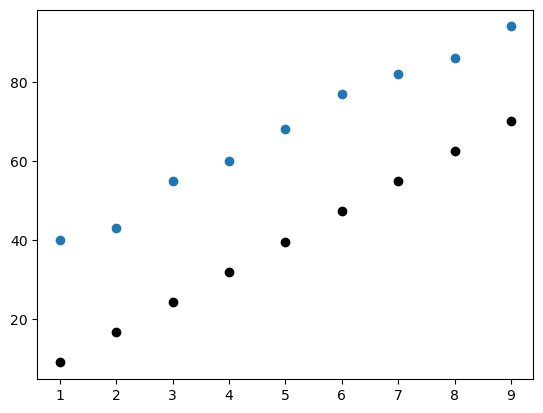

In [5]:
import numpy as np
import matplotlib.pyplot as plt

iter=1000  # Iterations
alpha=0.01 # Learning rate
# X: Dataset (matrix) with features
# y: Output
def predict(X,m,c):
    return m*X+c

def fit(X,y,iter,alpha):
    m=0
    c=0
    n=len(X)
    for i in range(iter):
        pred_y=predict(X,m,c)
        do_m=-(2/n)*np.sum((y-pred_y)*X)
        d_c=-(2/n)*np.sum((y-pred_y))
        m=m-alpha*do_m
        c=c-alpha*d_c
        return m,c

if __name__ == "__main__":
    X = np.array([1,2,3,4,5,6,7,8,9])
    y = np.array([40,43,55,60,68,77,82,86,94])
    plt.scatter(X,y)
    m,c = fit(X,y,iter,alpha) # Training
    new_y = predict(X,m,c) # Testing
    plt.scatter(X,new_y,color="black")
    plt.show()